# Φάση Ε: Model Evaluation & Σύγκριση

**Υπεύθυνος:** ML Engineer

**Μετρικές:**
- Accuracy
- Precision / Recall
- F1-Score
- ROC-AUC
- Confusion Matrix

**Οπτικοποιήσεις:**
1. Confusion Matrix (heatmap)
2. ROC Curve
3. Συγκριτικά bar charts
4. Πίνακας σύγκρισης

Εκκίνηση SparkSession...


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/09 23:48:02 WARN Utils: Your hostname, cachyos-x8664, resolves to a loopback address: 127.0.1.1; using 192.168.1.5 instead (on interface enp4s0)
26/06/09 23:48:02 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/09 23:48:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Φόρτωση προβλέψεων (Pandas)...

==================== Random Forest ====================
              precision    recall  f1-score   support

     Class 0       0.98      0.79      0.88       945
     Class 1       0.11      0.57      0.18        42

    accuracy                           0.78       987
   macro avg       0.54      0.68      0.53       987
weighted avg       0.94      0.78      0.85       987


==================== SVM ====================
              precision    recall  f1-score   support

     Class 0       0.98      0.74      0.84       945
     Class 1       0.10      0.62      0.17        42

    accuracy                           0.74       987
   macro avg       0.54      0.68      0.51       987
weighted avg       0.94      0.74      0.82       987


==================== Naive Bayes ====================
              precision    recall  f1-score   support

     Class 0       0.97      0.52      0.68       945
     Class 1       0.06      0.69      0.11    

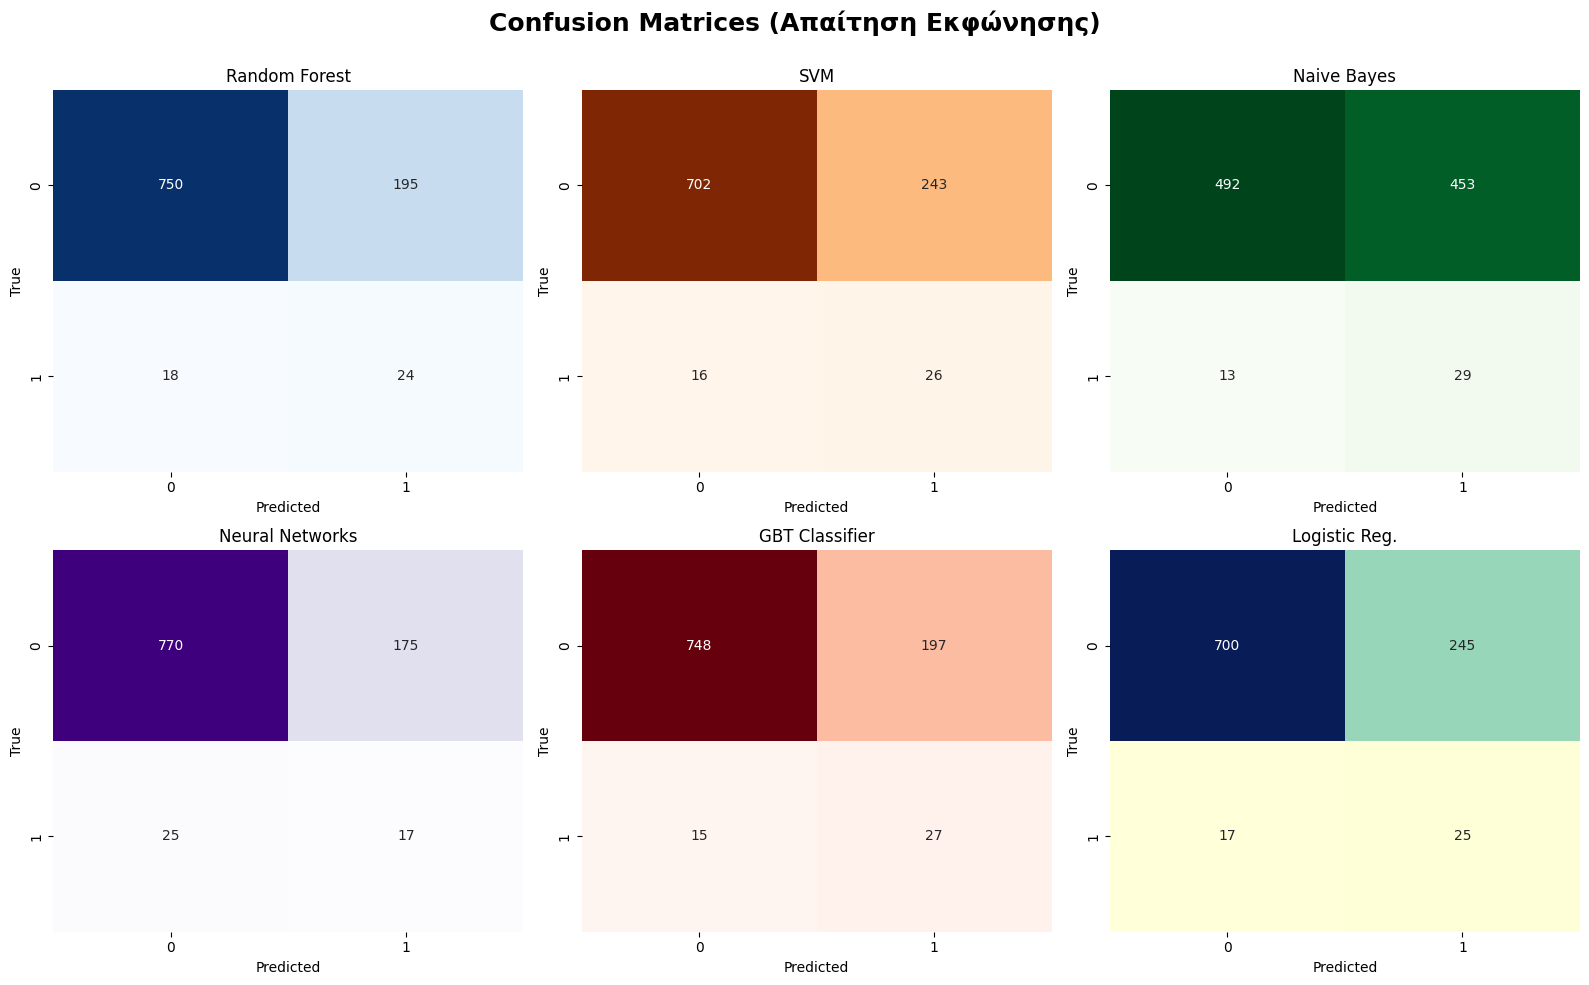

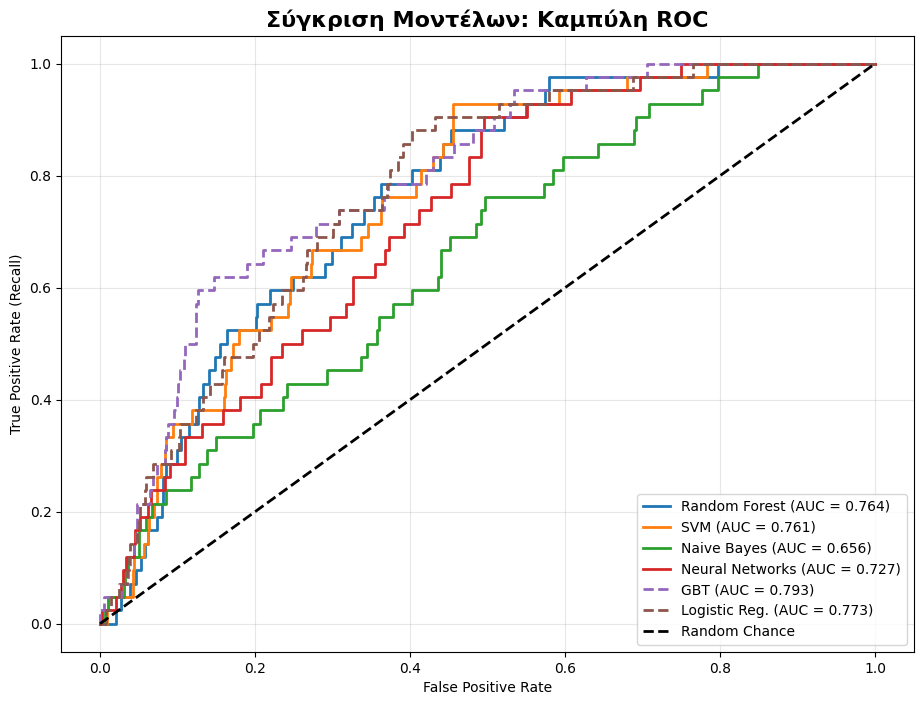

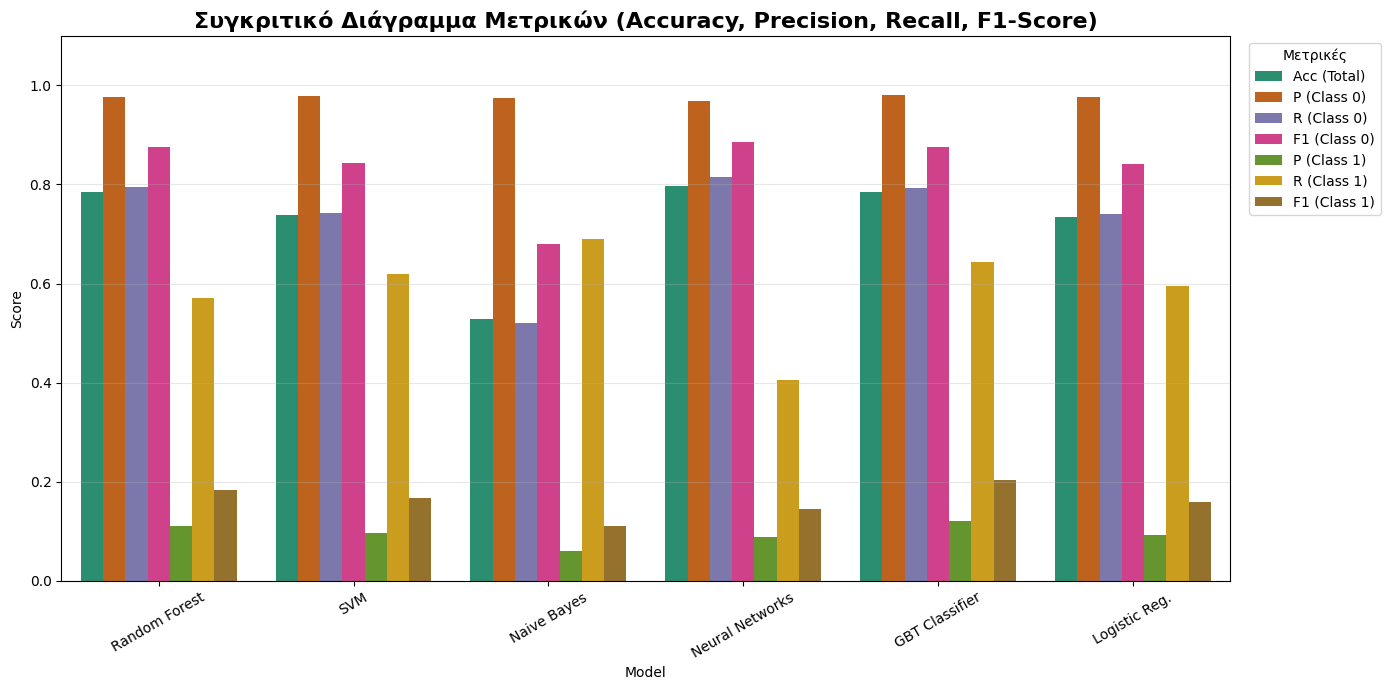

In [1]:
# Φάση Ε & ΣΤ: Model Evaluation, Σύγκριση & Συμπεράσματα (ΠΛΗΡΗΣ ΚΑΛΥΨΗ + F1-SCORE)
from pyspark.sql import SparkSession
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_curve, auc, 
                             precision_recall_fscore_support, classification_report)

print("Εκκίνηση SparkSession...")
spark = SparkSession.builder.appName("Evaluation_Metrics_Final").master("local[*]").getOrCreate()

print("Φόρτωση προβλέψεων (Pandas)...")
df_rf = spark.read.parquet("../data/rf_predictions.parquet").toPandas()
df_svm = spark.read.parquet("../data/svm_predictions.parquet").toPandas()
df_nb = spark.read.parquet("../data/nb_predictions.parquet").toPandas()
df_mlp = spark.read.parquet("../data/mlp_predictions.parquet").toPandas()
df_gbt = spark.read.parquet("../data/gbt_predictions.parquet").toPandas()
df_lr = spark.read.parquet("../data/lr_predictions.parquet").toPandas()

# Λεξικό για πλήρη αποθήκευση μετρικών ανά κλάση και συνολικά
metrics_dict = {
    "Model": [],
    "Acc (Total)": [],
    "P (Class 0)": [], "R (Class 0)": [], "F1 (Class 0)": [],
    "P (Class 1)": [], "R (Class 1)": [], "F1 (Class 1)": [],
    "ROC-AUC": []
}

def evaluate_model_full(df, model_name, prob_col="probability"):
    y_true = df['stroke'].values
    y_pred = df['prediction'].values
    
    # ROC-AUC
    y_prob = np.array([v[1] for v in df[prob_col]]) if prob_col == "probability" else np.array([v[1] for v in df[prob_col]])
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # Μετρικές ανά κλάση (Precision, Recall, F1)
    precisions, recalls, f1s, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    
    # Προσθήκη στο λεξικό
    metrics_dict["Model"].append(model_name)
    metrics_dict["Acc (Total)"].append(acc)
    metrics_dict["P (Class 0)"].append(precisions[0])
    metrics_dict["R (Class 0)"].append(recalls[0])
    metrics_dict["F1 (Class 0)"].append(f1s[0])
    metrics_dict["P (Class 1)"].append(precisions[1])
    metrics_dict["R (Class 1)"].append(recalls[1])
    metrics_dict["F1 (Class 1)"].append(f1s[1])
    metrics_dict["ROC-AUC"].append(roc_auc)
    
    cm = confusion_matrix(y_true, y_pred)
    
    # Εκτύπωση αναλυτικού classification report
    print(f"\n{'='*20} {model_name} {'='*20}")
    print(classification_report(y_true, y_pred, target_names=["Class 0", "Class 1"]))
    
    return fpr, tpr, roc_auc, cm

# Εκτέλεση αξιολόγησης (Τα 6 Τελικά Μοντέλα μας)
fpr_rf, tpr_rf, auc_rf, cm_rf = evaluate_model_full(df_rf, "Random Forest", "probability")
fpr_svm, tpr_svm, auc_svm, cm_svm = evaluate_model_full(df_svm, "SVM", "rawPrediction")
fpr_nb, tpr_nb, auc_nb, cm_nb = evaluate_model_full(df_nb, "Naive Bayes", "probability")
fpr_mlp, tpr_mlp, auc_mlp, cm_mlp = evaluate_model_full(df_mlp, "Neural Networks", "probability")
fpr_gbt, tpr_gbt, auc_gbt, cm_gbt = evaluate_model_full(df_gbt, "GBT Classifier", "probability")
fpr_lr, tpr_lr, auc_lr, cm_lr = evaluate_model_full(df_lr, "Logistic Reg.", "probability")


# ==========================================================
# 1. ΠΙΝΑΚΑΣ ΣΥΓΚΡΙΣΗΣ (Κεφάλαιο 4: Model Evaluation)
# ==========================================================
print("\n" + "="*80)
print("ΠΙΝΑΚΑΣ ΣΥΓΚΡΙΣΗΣ ΜΟΝΤΕΛΩΝ (Απαίτηση Εκφώνησης)")
print("="*80)
comparison_df = pd.DataFrame(metrics_dict).round(3)
print(comparison_df.to_string(index=False))
print("="*80)


# ==========================================================
# 2. ΟΠΤΙΚΟΠΟΙΗΣΗ 1: CONFUSION MATRICES (Τέλειο 2x3 Grid)
# ==========================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices (Απαίτηση Εκφώνησης)', fontsize=18, fontweight='bold')

cms = [cm_rf, cm_svm, cm_nb, cm_mlp, cm_gbt, cm_lr]
titles = ['Random Forest', 'SVM', 'Naive Bayes', 'Neural Networks', 'GBT Classifier', 'Logistic Reg.']
colors = ['Blues', 'Oranges', 'Greens', 'Purples', 'Reds', 'YlGnBu']

for i in range(len(colors)):
    row, col = i // 3, i % 3
    sns.heatmap(cms[i], annot=True, fmt='d', cmap=colors[i], cbar=False, ax=axes[row, col])
    axes[row, col].set_title(titles[i], fontsize=12)
    axes[row, col].set_xlabel('Predicted')
    axes[row, col].set_ylabel('True')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# ==========================================================
# 3. ΟΠΤΙΚΟΠΟΙΗΣΗ 2: ROC CURVES
# ==========================================================
plt.figure(figsize=(11, 8))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', lw=2)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})', lw=2)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.3f})', lw=2)
plt.plot(fpr_mlp, tpr_mlp, label=f'Neural Networks (AUC = {auc_mlp:.3f})', lw=2)
plt.plot(fpr_gbt, tpr_gbt, label=f'GBT (AUC = {auc_gbt:.3f})', lw=2, linestyle='--')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Reg. (AUC = {auc_lr:.3f})', lw=2, linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Chance')
plt.title('Σύγκριση Μοντέλων: Καμπύλη ROC', fontsize=16, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# ==========================================================
# 4. ΟΠΤΙΚΟΠΟΙΗΣΗ 3: ΣΥΓΚΡΙΤΙΚΑ BAR CHARTS
# ==========================================================
bar_df = comparison_df.drop(columns=["ROC-AUC"])
metrics_melted = bar_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_melted, palette='Dark2')
plt.title('Συγκριτικό Διάγραμμα Μετρικών (Accuracy, Precision, Recall, F1-Score)', fontsize=16, fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.xticks(rotation=30)
plt.legend(title='Μετρικές', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

spark.stop()